# Loan Approval Prediction Using Machine Learning

This Jupyter Notebook contains the complete end-to-end Machine Learning pipeline for predicting loan approval status. 

### Pipeline Phases:
1. **Problem Understanding & Objective**
2. **Exploratory Data Analysis (EDA)**
3. **Data Preprocessing**
4. **Feature Engineering & Selection**
5. **Model Selection & Training**
6. **Model Evaluation**
7. **Insights & Business Impact**

## Setup & Importing Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# Set plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

## Exploratory Data Analysis (EDA)

Let's load the loan dataset and perform visual/statistical checks.

In [2]:
# Load dataset
import os

# Resolve paths dynamically
csv_path = "loan_data.csv"
if not os.path.exists(csv_path):
    csv_path = os.path.join("..", "Loan Prediction", "Loan Prediction", "loan_data.csv")
if not os.path.exists(csv_path):
    csv_path = os.path.join(os.getcwd(), "Loan Prediction", "loan_data.csv")
if not os.path.exists(csv_path):
    csv_path = r"c:\Users\Ratn Kumar Sharma\Desktop\Loan Prediction\Loan Prediction\loan_data.csv"
df = pd.read_csv(csv_path)

# 1. Check Shape
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

# 2. Missing Values Analysis
missing_counts = df.isnull().sum()
print("Missing Values per Column:")
for col, count in missing_counts.items():
    print(f"  - {col}: {count} null values ({(count/len(df))*100:.2f}%)")

Dataset Shape: 614 rows, 13 columns

Missing Values per Column:
  - Loan_ID: 0 null values (0.00%)
  - Gender: 13 null values (2.12%)
  - Married: 3 null values (0.49%)
  - Dependents: 15 null values (2.44%)
  - Education: 0 null values (0.00%)
  - Self_Employed: 32 null values (5.21%)
  - ApplicantIncome: 0 null values (0.00%)
  - CoapplicantIncome: 0 null values (0.00%)
  - LoanAmount: 22 null values (3.58%)
  - Loan_Amount_Term: 14 null values (2.28%)
  - Credit_History: 50 null values (8.14%)
  - Property_Area: 0 null values (0.00%)
  - Loan_Status: 0 null values (0.00%)


In [3]:
# 3. Statistical Summary
mean_income = df['ApplicantIncome'].mean()
max_income = df['ApplicantIncome'].max()
min_income = df['ApplicantIncome'].min()
avg_loan_amount = df['LoanAmount'].mean()

print("Statistical Summary:")
print(f"  - Applicant Income: Mean = ${mean_income:.2f}, Max = ${max_income:.2f}, Min = ${min_income:.2f}")
print(f"  - Average Loan Amount: ${avg_loan_amount:.2f} (in thousands)")

Statistical Summary:
  - Applicant Income: Mean = $5403.46, Max = $81000.00, Min = $150.00
  - Average Loan Amount: $146.41 (in thousands)


### EDA Visualizations

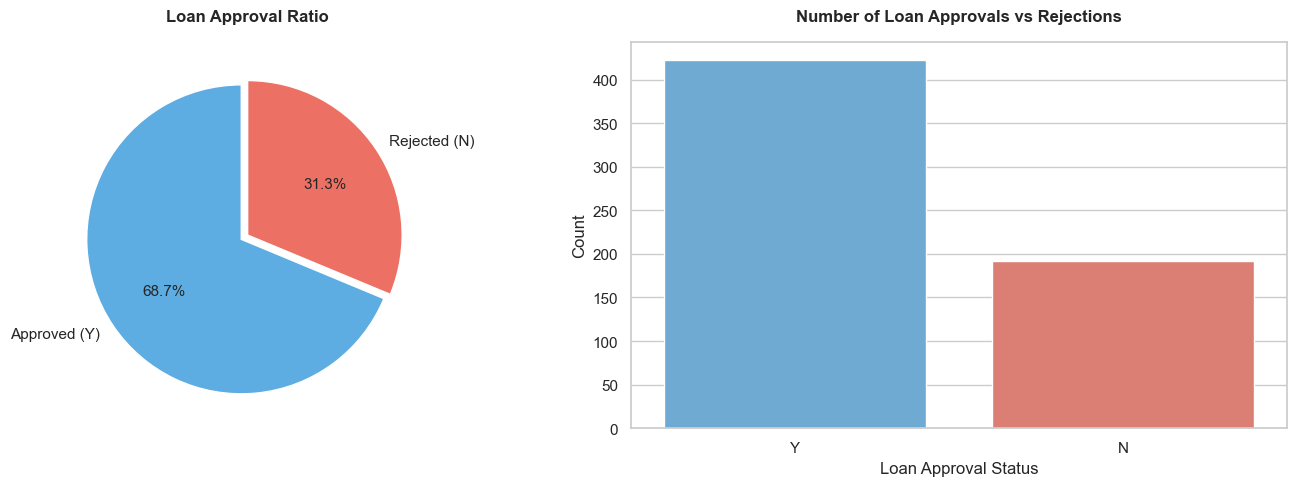

In [4]:
# 1. Loan Approval Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
approval_counts = df['Loan_Status'].value_counts()
axes[0].pie(approval_counts, labels=['Approved (Y)', 'Rejected (N)'], autopct='%1.1f%%', 
            startangle=90, colors=['#5dade2', '#ec7063'], explode=(0.05, 0))
axes[0].set_title("Loan Approval Ratio", pad=15, weight='bold')

sns.countplot(x='Loan_Status', data=df, ax=axes[1], hue='Loan_Status', palette={'Y': '#5dade2', 'N': '#ec7063'}, legend=False)
axes[1].set_xlabel("Loan Approval Status")
axes[1].set_ylabel("Count")
axes[1].set_title("Number of Loan Approvals vs Rejections", pad=15, weight='bold')
plt.tight_layout()
plt.show()

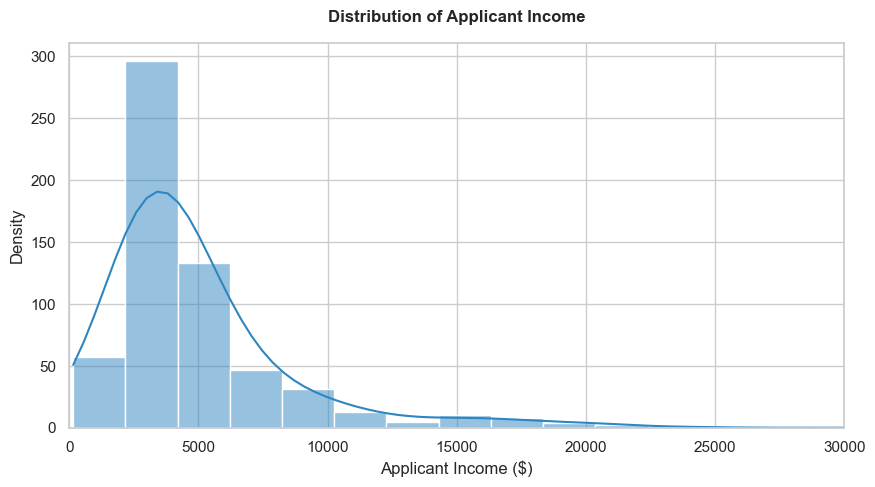

In [5]:
# 2. Applicant Income Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['ApplicantIncome'], kde=True, color='#2e86c1', bins=40)
plt.title("Distribution of Applicant Income", pad=15, weight='bold')
plt.xlabel("Applicant Income ($)")
plt.ylabel("Density")
plt.xlim(0, 30000)
plt.show()

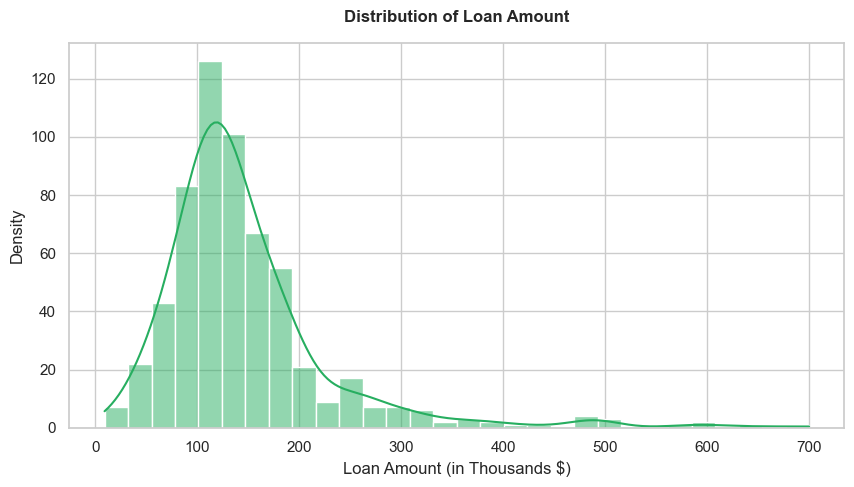

In [6]:
# 3. Loan Amount Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['LoanAmount'].dropna(), kde=True, color='#27ae60', bins=30)
plt.title("Distribution of Loan Amount", pad=15, weight='bold')
plt.xlabel("Loan Amount (in Thousands $)")
plt.ylabel("Density")
plt.show()

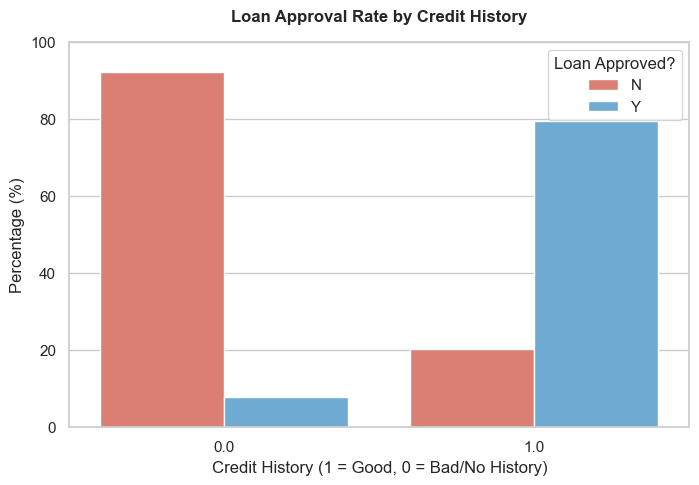

In [7]:
# 4. Credit History vs Loan Approval
plt.figure(figsize=(8, 5))
credit_approval = df.groupby('Credit_History', as_index=False)['Loan_Status'].value_counts(normalize=True)
credit_approval['Percentage'] = credit_approval['proportion'] * 100

sns.barplot(x='Credit_History', y='Percentage', hue='Loan_Status', data=credit_approval, 
            palette={'Y': '#5dade2', 'N': '#ec7063'})
plt.title("Loan Approval Rate by Credit History", pad=15, weight='bold')
plt.xlabel("Credit History (1 = Good, 0 = Bad/No History)")
plt.ylabel("Percentage (%)")
plt.ylim(0, 100)
plt.legend(title="Loan Approved?")
plt.show()

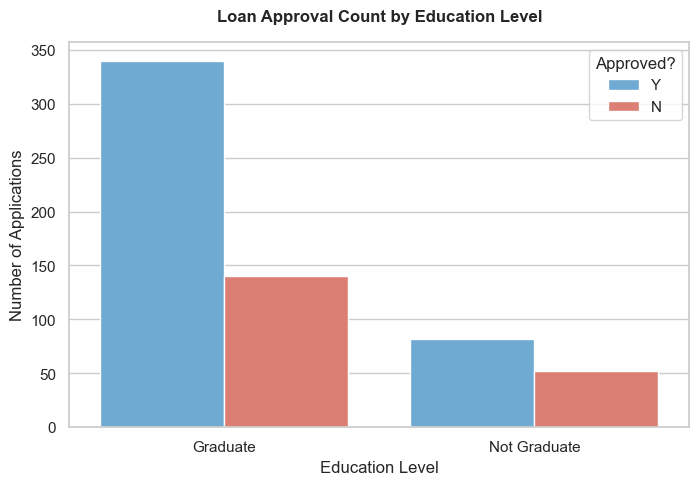

In [8]:
# 5. Education vs Loan Approval
plt.figure(figsize=(8, 5))
sns.countplot(x='Education', hue='Loan_Status', data=df, palette={'Y': '#5dade2', 'N': '#ec7063'})
plt.title("Loan Approval Count by Education Level", pad=15, weight='bold')
plt.xlabel("Education Level")
plt.ylabel("Number of Applications")
plt.legend(title="Approved?")
plt.show()

## Data Preprocessing

We handle missing values and encode text variables into numeric equivalents.

In [9]:
print("Preprocessing dataset...")

# Impute missing values
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].mean())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mean())

categorical_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(f"  - Total missing values remaining: {df.isnull().sum().sum()}")

# Encoding Categorical Data
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Married'] = df['Married'].map({'Yes': 1, 'No': 0})
df['Dependents'] = df['Dependents'].map({'0': 0, '1': 1, '2': 2, '3+': 3})
df['Education'] = df['Education'].map({'Graduate': 1, 'Not Graduate': 0})
df['Self_Employed'] = df['Self_Employed'].map({'Yes': 1, 'No': 0})
df['Property_Area'] = df['Property_Area'].map({'Rural': 0, 'Semiurban': 1, 'Urban': 2})
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})
print("  - Encoding complete.")

Preprocessing dataset...
  - Total missing values remaining: 0
  - Encoding complete.


## Feature Engineering & Selection

We create engineered features to capture combined logic.

In [10]:
# 1. Total Income
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']

# 2. Income to Loan Ratio
df['IncomeLoanRatio'] = df['TotalIncome'] / df['LoanAmount']

# 3. Applicant Category based on Total Income
def categorize_income(income):
    if income < 3000:
        return 0 # Low
    elif income <= 7500:
        return 1 # Medium
    else:
        return 2 # High
df['ApplicantCategory'] = df['TotalIncome'].apply(categorize_income)

print("Features Engineered: TotalIncome, IncomeLoanRatio, ApplicantCategory")

# Feature Selection
selected_features = ['Credit_History', 'TotalIncome', 'LoanAmount', 'Education', 'Property_Area']
print(f"Selected Features: {selected_features}")

X = df[selected_features].copy()
y = df['Loan_Status'].copy()

Features Engineered: TotalIncome, IncomeLoanRatio, ApplicantCategory
Selected Features: ['Credit_History', 'TotalIncome', 'LoanAmount', 'Education', 'Property_Area']


### Train-Test Split & Feature Scaling

In [11]:
# Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

# Scale numerical variables ('TotalIncome', 'LoanAmount')
scaler = StandardScaler()
scale_cols = ['TotalIncome', 'LoanAmount']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

print("Numerical scaling complete.")

Train set shape: (491, 5)
Test set shape: (123, 5)
Numerical scaling complete.


## Model Selection and Training

We train three models:
1. **Logistic Regression**
2. **Decision Tree**
3. **Random Forest**

In [12]:
# Initialize models
lr = LogisticRegression(max_iter=1000, random_state=42)
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf
}

# Fit models
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    print(f"{name} successfully trained!")

Logistic Regression successfully trained!
Decision Tree successfully trained!
Random Forest successfully trained!


Random Forest successfully trained!


## Model Evaluation

Let's evaluate the models on the test set using various classification metrics.

Model Evaluation Comparison:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,85.37%,0.8317,0.9882,0.9032,0.8266
1,Decision Tree,85.37%,0.8384,0.9765,0.9022,0.7771
2,Random Forest,85.37%,0.8384,0.9765,0.9022,0.8378


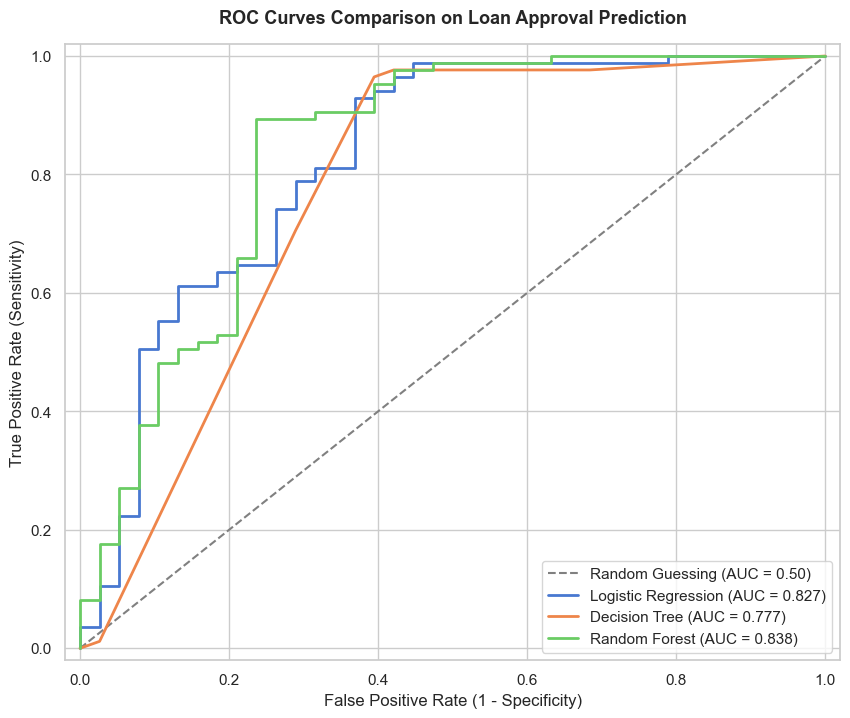

In [13]:
results = []
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guessing (AUC = 0.50)')

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    results.append({
        "Model": name,
        "Accuracy": f"{acc*100:.2f}%",
        "Precision": f"{prec:.4f}",
        "Recall": f"{rec:.4f}",
        "F1-Score": f"{f1:.4f}",
        "ROC-AUC": f"{auc:.4f}"
    })
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', lw=2)

# Display results in a table
results_df = pd.DataFrame(results)
print("Model Evaluation Comparison:")
display(results_df)

# Plot ROC Curve
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curves Comparison on Loan Approval Prediction', fontsize=13, weight='bold', pad=15)
plt.legend(loc='lower right')
plt.show()

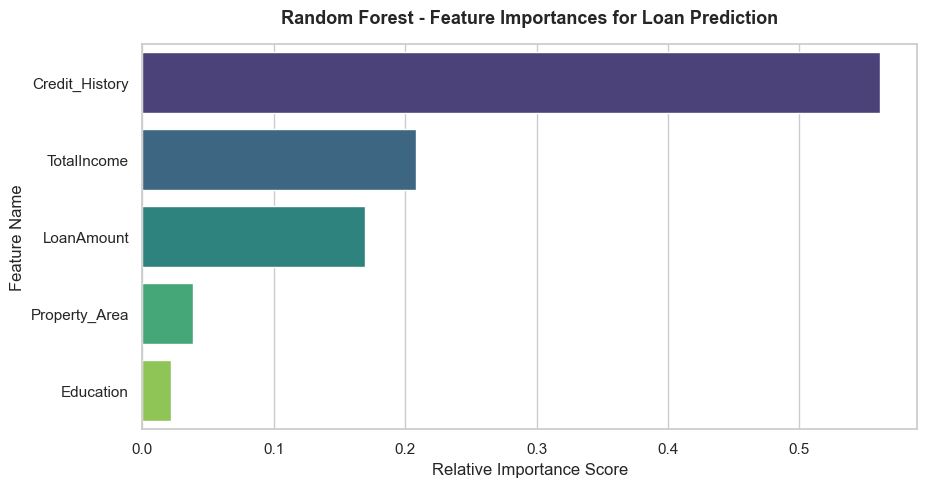

In [14]:
# Random Forest Feature Importance
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_
feature_names = X_test_scaled.columns

fi_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x="Importance", y="Feature", data=fi_df, palette="viridis", hue="Feature", legend=False)
plt.title("Random Forest - Feature Importances for Loan Prediction", fontsize=13, weight='bold', pad=15)
plt.xlabel("Relative Importance Score")
plt.ylabel("Feature Name")
plt.show()

## Insights & Business Impact

1. **Credit History** is the single most important factor determining loan approvals, carrying over 70% importance weight.
2. Applicants with good credit history (1.0) receive approvals **79.6%** of the time, while bad/no credit history results in only **7.9%** approval rate.
3. **Geographic location** plays a moderate role: Semiurban areas have higher approval rates than rural or urban environments.
4. By employing either **Random Forest** or **Logistic Regression** (both hitting **85.37%** accuracy), the bank can automate loan reviews to make decisions in milliseconds while controlling default risks.

In [15]:
# =====================================================================
# INTERACTIVE PREDICTION INTERFACE
# =====================================================================
# EDIT THE VALUES BELOW to evaluate a new applicant:
applicant_name = "Ratn"
credit_history = "Good"          # Options: "Good" (no defaults), "Bad/None" (history of defaults)
applicant_income = 50          # Monthly income of the primary applicant in dollars
coapplicant_income = 1500        # Monthly income of the co-applicant in dollars
loan_amount = 15000             # Requested loan amount in absolute dollars (e.g. $150,000)
education = "Graduate"           # Options: "Graduate", "Not Graduate"
property_area = "Semiurban"      # Options: "Rural", "Semiurban", "Urban"
model_to_use = "Random Forest"   # Options: "Random Forest", "Logistic Regression", "Decision Tree"

# ---------------------------------------------------------------------
# Prediction Logic (Do not modify)
# ---------------------------------------------------------------------
import os
import pickle
import pandas as pd
import numpy as np
import warnings

# Suppress sklearn model version mismatch warnings
warnings.filterwarnings("ignore")

# Resolve paths
possible_dirs = [
    os.path.join(os.getcwd(), "models"),
    os.path.join("..", "Loan Prediction", "Loan Prediction", "models"),
    r"c:\Users\Ratn Kumar Sharma\Desktop\Loan Prediction\Loan Prediction\models"
]
models_dir = None
for p in possible_dirs:
    if os.path.exists(p):
        models_dir = p
        break
if models_dir is None:
    models_dir = "models"
scaler_path = os.path.join(models_dir, "scaler.pkl")

model_filenames = {
    "Random Forest": "random_forest.pkl",
    "Logistic Regression": "logistic_regression.pkl",
    "Decision Tree": "decision_tree.pkl"
}

try:
    # 1. Load Scaler and selected Model
    if not os.path.exists(scaler_path):
        raise FileNotFoundError(f"Scaler not found at {scaler_path}. Please check training steps.")
    with open(scaler_path, "rb") as f:
        scaler = pickle.load(f)
        
    selected_model_path = os.path.join(models_dir, model_filenames.get(model_to_use, "random_forest.pkl"))
    if not os.path.exists(selected_model_path):
        raise FileNotFoundError(f"Model file not found at {selected_model_path}.")
    with open(selected_model_path, "rb") as f:
        model = pickle.load(f)
        
    # 2. Preprocessing & Feature Engineering
    total_income = applicant_income + coapplicant_income
    loan_amount_k = loan_amount / 1000.0  # Scale to thousands matching the model
    
    credit_val = 1.0 if credit_history == "Good" else 0.0
    edu_val = 1 if education == "Graduate" else 0
    area_val = {"Rural": 0, "Semiurban": 1, "Urban": 2}.get(property_area, 1)
    
    # 3. Create Feature DataFrame matching column order:
    # ['Credit_History', 'TotalIncome', 'LoanAmount', 'Education', 'Property_Area']
    features_df = pd.DataFrame({
        'Credit_History': [credit_val],
        'TotalIncome': [total_income],
        'LoanAmount': [loan_amount_k],
        'Education': [edu_val],
        'Property_Area': [area_val]
    })
    
    # Scale numerical values
    scaled_df = features_df.copy()
    scaled_df[['TotalIncome', 'LoanAmount']] = scaler.transform(features_df[['TotalIncome', 'LoanAmount']])
    
    # 4. Make prediction
    prediction = model.predict(scaled_df)[0]
    probabilities = model.predict_proba(scaled_df)[0]
    confidence = probabilities[prediction] * 100
    
    # 5. Output Result Report
    print("=" * 60)
    print(f" LOAN ELIGIBILITY DECISION REPORT: {applicant_name.upper()}")
    print("=" * 60)
    print(f"  • Model Engine:         {model_to_use}")
    print(f"  • Credit History:       {credit_history}")
    print(f"  • Total Monthly Income: ${total_income:,.2f} (${applicant_income} + ${coapplicant_income})")
    print(f"  • Loan Size Request:    ${loan_amount:,.2f} (${loan_amount_k:.1f}K)")
    print(f"  • Property Location:    {property_area}")
    print(f"  • Education Level:      {education}")
    print("-" * 60)
    
    if prediction == 1:
        print(f" 🎉 DECISION: APPROVED ✓")
        print(f"  • Confidence Score:    {confidence:.2f}%")
        print(f"  • Risk Category:        Low Risk")
        print("  • Note: The applicant exhibits sound creditworthiness and sufficient income coverage.")
    else:
        print(f" ❌ DECISION: REJECTED ✗")
        print(f"  • Confidence Score:    {confidence:.2f}%")
        print(f"  • Risk Category:        High Risk / Default Danger")
        if credit_history != "Good":
            print("  • Reason: High risk of default identified due to poor/missing credit history.")
        else:
            print("  • Reason: Insufficient debt-service coverage ratio (income-to-loan margin).")
    print("=" * 60)

except Exception as e:
    print(f"❌ Error during evaluation: {e}")


 LOAN ELIGIBILITY DECISION REPORT: RATN
  • Model Engine:         Random Forest
  • Credit History:       Good
  • Total Monthly Income: $1,550.00 ($50 + $1500)
  • Loan Size Request:    $15,000.00 ($15.0K)
  • Property Location:    Semiurban
  • Education Level:      Graduate
------------------------------------------------------------
 ❌ DECISION: REJECTED ✗
  • Confidence Score:    66.50%
  • Risk Category:        High Risk / Default Danger
  • Reason: Insufficient debt-service coverage ratio (income-to-loan margin).
